In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import fisher_exact
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests


In [8]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE       = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
FEAT_TABLE = os.path.join(BASE, "feat_table.xlsx")
OUT_DIR    = os.path.join(BASE, "sequence_similarity")
os.makedirs(OUT_DIR, exist_ok=True)

AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
AA_INDEX = {aa: i for i, aa in enumerate(AA_ORDER)}

# BLOSUM62 substitution matrix (symmetric, 20x20, indexed by AA_ORDER)
# Source: Henikoff & Henikoff (1992) PNAS 89:10915
_BLOSUM62_RAW = [
# A   C   D   E   F   G   H   I   K   L   M   N   P   Q   R   S   T   V   W   Y
[ 4,  0, -2, -1, -2,  0, -2, -1, -1, -1, -1, -2, -1, -1, -1,  1,  0,  0, -3, -2],  # A
[ 0,  9, -3, -4, -2, -3, -3, -1, -3, -1, -1, -3, -3, -3, -3, -1, -1, -1, -2, -2],  # C
[-2, -3,  6,  2, -3, -1, -1, -3, -1, -4, -3,  1, -1,  0, -2,  0, -1, -3, -4, -3],  # D
[-1, -4,  2,  5, -3, -2,  0, -3,  1, -3, -2,  0, -1,  2,  0,  0, -1, -2, -3, -2],  # E
[-2, -2, -3, -3,  6, -3, -1,  0, -3,  0,  0, -3, -4, -3, -3, -2, -2, -1,  1,  3],  # F
[ 0, -3, -1, -2, -3,  6, -2, -4, -2, -4, -3,  0, -2, -2, -2,  0, -2, -3, -2, -3],  # G
[-2, -3, -1,  0, -1, -2,  8, -3, -1, -3, -2,  1, -2,  0,  0, -1, -2, -3, -2,  2],  # H
[-1, -1, -3, -3,  0, -4, -3,  4, -3,  2,  1, -3, -3, -3, -3, -2, -1,  3, -3, -1],  # I
[-1, -3, -1,  1, -3, -2, -1, -3,  5, -2, -1,  0, -1,  1,  2,  0, -1, -2, -3, -2],  # K
[-1, -1, -4, -3,  0, -4, -3,  2, -2,  4,  2, -3, -3, -2, -2, -2, -1,  1, -2, -1],  # L
[-1, -1, -3, -2,  0, -3, -2,  1, -1,  2,  5, -2, -2,  0, -1, -1, -1,  1, -1, -1],  # M
[-2, -3,  1,  0, -3,  0,  1, -3,  0, -3, -2,  6, -2,  0,  0,  1,  0, -3, -4, -2],  # N
[-1, -3, -1, -1, -4, -2, -2, -3, -1, -3, -2, -2,  7, -1, -2, -1, -1, -2, -4, -3],  # P
[-1, -3,  0,  2, -3, -2,  0, -3,  1, -2,  0,  0, -1,  5,  1,  0, -1, -2, -2, -1],  # Q
[-1, -3, -2,  0, -3, -2,  0, -3,  2, -2, -1,  0, -2,  1,  5, -1, -1, -3, -3, -2],  # R
[ 1, -1,  0,  0, -2,  0, -1, -2,  0, -2, -1,  1, -1,  0, -1,  4,  1, -2, -3, -2],  # S
[ 0, -1, -1, -1, -2, -2, -2, -1, -1, -1, -1,  0, -1, -1, -1,  1,  5,  0, -2, -2],  # T
[ 0, -1, -3, -2, -1, -3, -3,  3, -2,  1,  1, -3, -2, -2, -3, -2,  0,  4, -3, -1],  # V
[-3, -2, -4, -3,  1, -2, -2, -3, -3, -2, -1, -4, -4, -2, -3, -3, -2, -3, 11,  2],  # W
[-2, -2, -3, -2,  3, -3,  2, -1, -2, -1, -1, -2, -3, -1, -2, -2, -2, -1,  2,  7],  # Y
]
BLOSUM62 = np.array(_BLOSUM62_RAW, dtype=np.float32)
# Max self-score per AA for normalisation
BLOSUM62_SELFSCORES = np.array([BLOSUM62[i, i] for i in range(20)])

BINARY_LABEL = {
    "binder":    1,
    "nonbinder": 0,
    "low_pkt":   0,
    "fail_gate": 0,
}
DISPLAY_LABEL = {
    "binder":    "Binder",
    "nonbinder": "False Positive",
    "low_pkt":   "Low Confidence",
    "fail_gate": "Fail Geometry",
}
GROUP_COLORS = {
    "binder":    "#648FFF",
    "nonbinder": "#DC267F",
    "low_pkt":   "#FE6100",
    "fail_gate": "#FFB000",
}


In [9]:
# ── Data loader ────────────────────────────────────────────────────────────────

def load_feat_table(path):
    df = pd.read_excel(path, sheet_name="all_feats_new")
    df.columns = df.columns.str.strip()
    rename = {}
    for col in df.columns:
        if col.lower() == "sequence": rename[col] = "sequence"
        if col.lower() == "group":    rename[col] = "group"
        if col.lower() == "name":     rename[col] = "name"
    df = df.rename(columns=rename)
    df["group"]    = df["group"].astype(str).str.strip().str.lower()
    df["sequence"] = df["sequence"].astype(str).str.strip()
    df = df[df["group"].isin(BINARY_LABEL)].reset_index(drop=True)
    df = df[df["sequence"].str.len() > 0].reset_index(drop=True)
    print(f"Loaded {len(df)} sequences.")
    print(df["group"].value_counts().to_string())
    return df


# ── Variable positions ─────────────────────────────────────────────────────────

def variable_positions(sequences, min_entropy=0.1):
    L = len(sequences[0])
    entropies = []
    for pos in range(L):
        counts = np.zeros(20)
        for seq in sequences:
            idx = AA_INDEX.get(seq[pos].upper())
            if idx is not None: counts[idx] += 1
        freq = counts / counts.sum() if counts.sum() > 0 else counts
        freq = freq[freq > 0]
        entropies.append(-np.sum(freq * np.log2(freq)) if len(freq) else 0)
    return np.where(np.array(entropies) >= min_entropy)[0]


# ── 1. Hamming distance matrix ─────────────────────────────────────────────────

def hamming_distance_matrix(sequences):
    """
    Pairwise fractional Hamming distance between sequences of equal length.
    Returns (n x n) matrix with values in [0, 1].
    """
    n, L = len(sequences), len(sequences[0])
    # Integer-encode sequences
    S = np.array([[AA_INDEX.get(aa.upper(), -1) for aa in seq]
                  for seq in sequences], dtype=np.int8)
    D = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i+1, n):
            d = np.mean(S[i] != S[j])
            D[i, j] = D[j, i] = d
    return D


# ── 2. BLOSUM62 similarity matrix ─────────────────────────────────────────────

def blosum62_similarity_matrix(sequences):
    """
    Pairwise BLOSUM62-based similarity score, normalised to [0, 1].
    Normalisation: score(i,j) / sqrt(score(i,i) * score(j,j))
    so identical sequences → 1.0, divergent → lower values.
    """
    n, L = len(sequences), len(sequences[0])
    S = np.array([[AA_INDEX.get(aa.upper(), -1) for aa in seq]
                  for seq in sequences], dtype=np.int32)

    def seq_score(a, b):
        total = 0
        for pos in range(L):
            ia, ib = a[pos], b[pos]
            if ia >= 0 and ib >= 0:
                total += BLOSUM62[ia, ib]
        return total

    # Self-scores for normalisation
    self_scores = np.array([seq_score(S[i], S[i]) for i in range(n)])

    sim = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i, n):
            raw = seq_score(S[i], S[j])
            denom = np.sqrt(self_scores[i] * self_scores[j])
            val = raw / denom if denom > 0 else 0.0
            sim[i, j] = sim[j, i] = val
    return sim


# ── 3. Position-wise Fisher's exact test ───────────────────────────────────────

def position_fisher_test(sequences, groups, var_pos, alpha=0.05):
    """
    For each variable position, test whether the amino acid distribution
    differs significantly between binders and nonbinders using Fisher's
    exact test (each AA: binder/nonbinder count vs rest).

    Returns a DataFrame with columns:
        position, amino_acid, binder_freq, nonbinder_freq, odds_ratio, pval, padj
    sorted by adjusted p-value.
    """
    binder_seqs    = [seq for seq, g in zip(sequences, groups) if g == "binder"]
    nonbinder_seqs = [seq for seq, g in zip(sequences, groups) if g != "binder"]
    n_b  = len(binder_seqs)
    n_nb = len(nonbinder_seqs)

    rows = []
    for pos in var_pos:
        b_counts  = {aa: 0 for aa in AA_ORDER}
        nb_counts = {aa: 0 for aa in AA_ORDER}
        for seq in binder_seqs:
            aa = seq[pos].upper()
            if aa in b_counts: b_counts[aa] += 1
        for seq in nonbinder_seqs:
            aa = seq[pos].upper()
            if aa in nb_counts: nb_counts[aa] += 1

        for aa in AA_ORDER:
            a = b_counts[aa]          # binder has aa
            b = n_b  - a              # binder doesn't have aa
            c = nb_counts[aa]         # nonbinder has aa
            d = n_nb - c              # nonbinder doesn't have aa
            if a + c == 0:            # AA absent in both groups
                continue
            _, pval = fisher_exact([[a, b], [c, d]], alternative="two-sided")
            rows.append({
                "position":      pos + 1,
                "amino_acid":    aa,
                "binder_count":  a,
                "nonbinder_count": c,
                "binder_freq":   round(a / n_b, 3),
                "nonbinder_freq": round(c / n_nb, 3),
                "pval":          pval,
            })

    df = pd.DataFrame(rows)
    _, padj, _, _ = multipletests(df["pval"], method="fdr_bh")
    df["padj"] = padj
    df = df.sort_values("padj").reset_index(drop=True)
    return df


# ── 4. Sequence logo builder ───────────────────────────────────────────────────

def build_pwm(sequences, var_pos, pseudocount=0.01):
    """
    Build a position weight matrix (counts) for a set of sequences
    at variable positions only.
    Returns a DataFrame with shape (n_var_pos, 20) indexed by position label.
    """
    n = len(sequences)
    rows = []
    for pos in var_pos:
        counts = {aa: pseudocount for aa in AA_ORDER}
        for seq in sequences:
            aa = seq[pos].upper()
            if aa in counts: counts[aa] += 1
        total = sum(counts.values())
        rows.append({aa: counts[aa] / total for aa in AA_ORDER})
    index = [f"pos{pos+1}" for pos in var_pos]
    return pd.DataFrame(rows, index=index, columns=AA_ORDER)


# ── Heatmap helper ─────────────────────────────────────────────────────────────

def clustered_heatmap(matrix, labels, groups, title, cmap, out_name,
                      vmin=None, vmax=None):
    """
    Plot a clustered heatmap of a pairwise matrix with group colour strip.
    """
    dist = matrix if cmap == "viridis" else 1 - matrix
    dist = np.clip(dist, 0, None)
    Z    = linkage(squareform(dist), method="average")
    order = dendrogram(Z, no_plot=True)["leaves"]

    mat_ord  = matrix[np.ix_(order, order)]
    grp_ord  = [groups[i] for i in order]

    fig = plt.figure(figsize=(10, 9))
    gs  = fig.add_gridspec(2, 2, width_ratios=[0.04, 1],
                           height_ratios=[0.04, 1], hspace=0.02, wspace=0.02)
    ax_strip_top  = fig.add_subplot(gs[0, 1])
    ax_strip_left = fig.add_subplot(gs[1, 0])
    ax_heat       = fig.add_subplot(gs[1, 1])

    # Colour strip
    strip = np.array([list(GROUP_COLORS.keys()).index(g)
                      if g in GROUP_COLORS else 0 for g in grp_ord])
    strip_colors = np.array([GROUP_COLORS.get(g, "#aaaaaa") for g in grp_ord])

    for i, col in enumerate(strip_colors):
        ax_strip_top.add_patch(plt.Rectangle((i, 0), 1, 1, color=col))
        ax_strip_left.add_patch(plt.Rectangle((0, i), 1, 1, color=col))
    ax_strip_top.set_xlim(0, len(order)); ax_strip_top.set_ylim(0, 1)
    ax_strip_left.set_xlim(0, 1); ax_strip_left.set_ylim(0, len(order))
    for ax in [ax_strip_top, ax_strip_left]:
        ax.set_xticks([]); ax.set_yticks([])

    # Heatmap
    im = ax_heat.imshow(mat_ord, aspect="auto", cmap=cmap,
                        vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_heat.set_xticks([]); ax_heat.set_yticks([])
    plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02)
    fig.suptitle(title, fontsize=13, y=0.98)

    # Legend
    handles = [mpatches.Patch(color=c, label=DISPLAY_LABEL[g])
               for g, c in GROUP_COLORS.items()]
    fig.legend(handles=handles, loc="lower right",
               fontsize=9, framealpha=0.9)
    plt.savefig(os.path.join(OUT_DIR, out_name), dpi=150, bbox_inches="tight")
    plt.show()


Loaded 130 sequences.
group
nonbinder    74
binder       37
fail_gate    10
low_pkt       9
Variable positions (24 total): [np.int64(2), np.int64(29), np.int64(43), np.int64(59), np.int64(60), np.int64(80), np.int64(81), np.int64(83), np.int64(90), np.int64(92), np.int64(94), np.int64(108), np.int64(110), np.int64(117), np.int64(118), np.int64(120), np.int64(122), np.int64(134), np.int64(141), np.int64(159), np.int64(160), np.int64(163), np.int64(164), np.int64(167)]
Variable-position subsequence length: 24 residues
Positions where a single AA appears in ≥80% of binders:
 position amino_acid  binder_freq  nonbinder_freq
        2          A        0.838           1.000
       29          S        0.838           1.000
       43          E        0.838           1.000
       60          H        0.838           1.000
       80          D        0.838           1.000
       81          D        0.892           0.151
       83          L        0.919           0.097
       90          N  

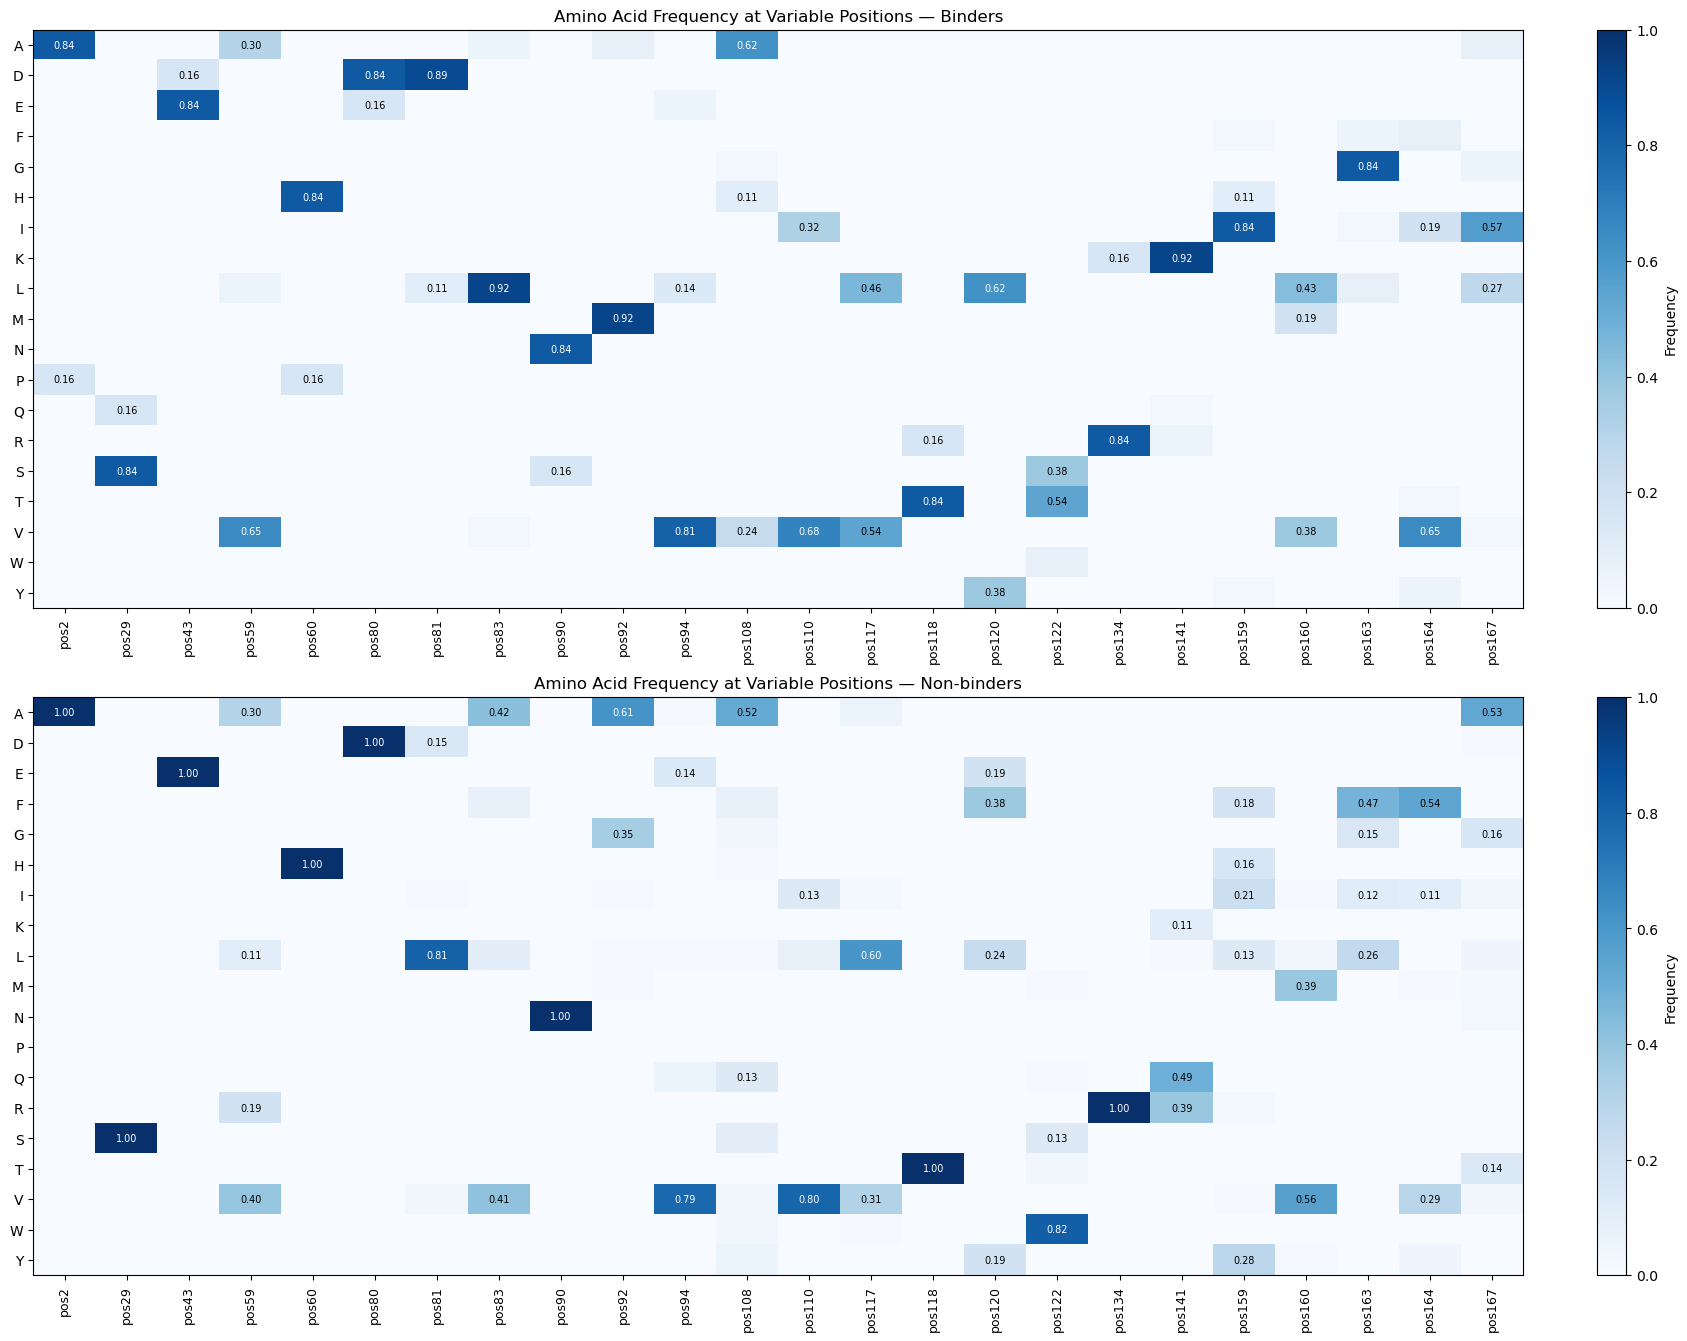


Running position-wise Fisher's exact test...

Significant positions (FDR-adjusted p < 0.05): 24

Top 20 position-AA associations:
 position amino_acid  binder_count  nonbinder_count  binder_freq  nonbinder_freq         pval         padj
       92          M            34                1        0.919           0.011 1.193831e-26 1.193831e-24
       83          L            34                9        0.919           0.097 1.485046e-19 7.425232e-18
      141          K            34               10        0.919           0.108 6.316024e-19 2.105341e-17
       81          D            33               14        0.892           0.151 1.577949e-15 3.944872e-14
      122          W             3               76        0.081           0.817 2.930886e-15 5.861772e-14
       81          L             4               75        0.108           0.806 1.061416e-13 1.769027e-12
      163          G            31               14        0.838           0.151 1.857243e-13 2.653205e-12
      167    

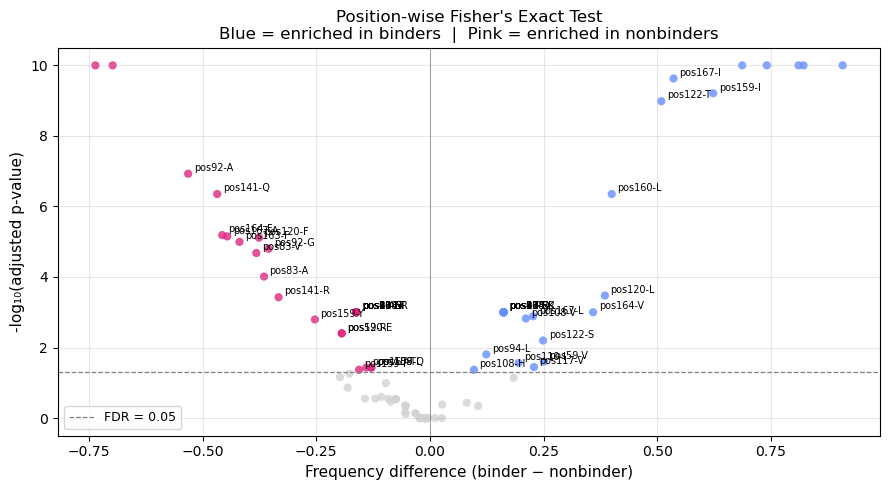


Amino acids retained after filtering: 19 / 20
  ['A', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


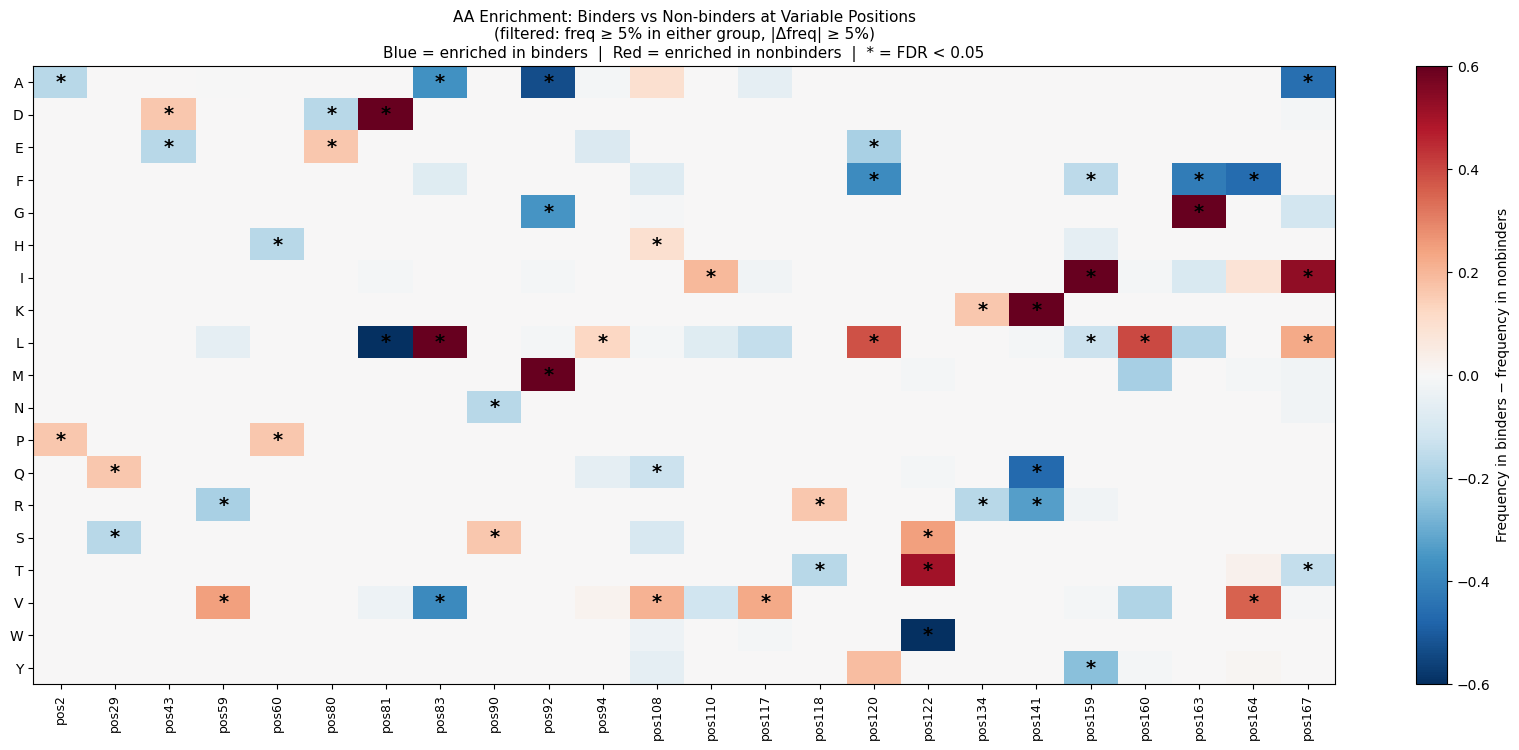


Sequence Similarity Analysis Summary
  Sequences analysed     : 130
  Variable positions     : 24
  Binders                : 37
  Non-binders            : 93

  Mean binder-binder Hamming     : 0.3529
  Mean cross-group Hamming       : 0.5430
  Mean binder-binder BLOSUM62    : 0.6609
  Mean cross-group BLOSUM62      : 0.3913

  Significant positions (FDR<0.05): 24
  Top enriched in binders:
    pos92-M: binder=0.92, nonbinder=0.01, padj=1.194e-24
    pos83-L: binder=0.92, nonbinder=0.10, padj=7.425e-18
    pos141-K: binder=0.92, nonbinder=0.11, padj=2.105e-17
    pos81-D: binder=0.89, nonbinder=0.15, padj=3.945e-14
    pos163-G: binder=0.84, nonbinder=0.15, padj=2.653e-12

Outputs written to: /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/sequence_similarity


In [12]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
df        = load_feat_table(FEAT_TABLE)
sequences = df["sequence"].tolist()
groups    = df["group"].tolist()
seq_ids   = df["name"].tolist() if "name" in df.columns else [f"seq{i}" for i in range(len(df))]
y         = np.array([BINARY_LABEL[g] for g in groups])
is_binder = np.array(groups) == "binder"

var_pos = variable_positions(sequences)
print(f"Variable positions ({len(var_pos)} total): {[p+1 for p in var_pos]}")

# Subsequences containing only variable positions
# Used for distance/similarity matrices so conserved scaffold positions
# don't dilute the signal from the designed residues
var_sequences = ["".join(seq[p] for p in var_pos) for seq in sequences]
print(f"Variable-position subsequence length: {len(var_sequences[0])} residues")

# ── 2. Per-position amino acid frequency table ────────────────────────────────
binder_seqs    = [seq for seq, g in zip(sequences, groups) if g == "binder"]
nonbinder_seqs = [seq for seq, g in zip(sequences, groups) if g != "binder"]

rows = []
for pos in var_pos:
    for aa in AA_ORDER:
        b_freq  = sum(seq[pos].upper() == aa for seq in binder_seqs)    / len(binder_seqs)
        nb_freq = sum(seq[pos].upper() == aa for seq in nonbinder_seqs) / len(nonbinder_seqs)
        if b_freq > 0 or nb_freq > 0:
            rows.append({
                "position":      pos + 1,
                "amino_acid":    aa,
                "binder_freq":   round(b_freq,  3),
                "nonbinder_freq": round(nb_freq, 3),
                "binder_count":  round(b_freq  * len(binder_seqs)),
                "nonbinder_count": round(nb_freq * len(nonbinder_seqs)),
            })

freq_df = pd.DataFrame(rows)

# Flag positions where one AA dominates (≥80%) in binders
conserved = freq_df[(freq_df["binder_freq"] >= 0.80)].copy()
print("Positions where a single AA appears in ≥80% of binders:")
print(conserved[["position","amino_acid","binder_freq",
                 "nonbinder_freq"]].to_string(index=False))
freq_df.to_csv(os.path.join(OUT_DIR, "aa_frequencies.csv"), index=False)

# ── 3. Frequency heatmap: binders only ────────────────────────────────────────
# Pivot to (AA x position) frequency matrix for binders
binder_pivot = freq_df.pivot(index="amino_acid", columns="position",
                              values="binder_freq").fillna(0)

# Keep only AAs that appear in at least one position at ≥5%
keep_aa = binder_pivot.index[binder_pivot.max(axis=1) >= 0.05].tolist()
binder_pivot = binder_pivot.loc[keep_aa]

fig, axes = plt.subplots(2, 1, figsize=(max(10, len(var_pos) * 0.7),
                                        max(4, len(keep_aa) * 0.35) * 2),
                         constrained_layout=True)

for ax, (grp_label, pivot_data) in zip(axes, [
    ("Binders",     freq_df.pivot(index="amino_acid", columns="position",
                                  values="binder_freq").fillna(0).loc[keep_aa]),
    ("Non-binders", freq_df.pivot(index="amino_acid", columns="position",
                                  values="nonbinder_freq").fillna(0).loc[keep_aa]),
]):
    im = ax.imshow(pivot_data.values, cmap="Blues", vmin=0, vmax=1,
                   aspect="auto", interpolation="nearest")
    ax.set_yticks(range(len(keep_aa)))
    ax.set_yticklabels(keep_aa, fontsize=10)
    ax.set_xticks(range(len(var_pos)))
    ax.set_xticklabels([f"pos{p+1}" for p in var_pos], rotation=90, fontsize=9)
    plt.colorbar(im, ax=ax, label="Frequency")

    # Annotate each cell with the frequency value if ≥ 0.10
    for row_i, aa in enumerate(keep_aa):
        for col_i, pos in enumerate(var_pos):
            val = pivot_data.iloc[row_i, col_i]
            if val >= 0.10:
                ax.text(col_i, row_i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7,
                        color="white" if val > 0.6 else "black")

    ax.set_title(f"Amino Acid Frequency at Variable Positions — {grp_label}",
                 fontsize=12)

fig.savefig(os.path.join(OUT_DIR, "aa_frequency_heatmap.png"), dpi=150)
plt.show()

# ── 4. Position-wise Fisher's exact test ──────────────────────────────────────
print("\nRunning position-wise Fisher's exact test...")
fisher_df = position_fisher_test(sequences, groups, var_pos)

sig = fisher_df[fisher_df["padj"] < 0.05]
print(f"\nSignificant positions (FDR-adjusted p < 0.05): {sig['position'].nunique()}")
print("\nTop 20 position-AA associations:")
print(fisher_df.head(20).to_string(index=False))
fisher_df.to_csv(os.path.join(OUT_DIR, "fisher_test_results.csv"), index=False)

# Volcano plot
freq_diff = fisher_df["binder_freq"] - fisher_df["nonbinder_freq"]
log_padj  = -np.log10(fisher_df["padj"].clip(lower=1e-10))

fig, ax = plt.subplots(figsize=(9, 5))
colors = np.where(fisher_df["padj"] < 0.05,
                  np.where(freq_diff > 0, "#648FFF", "#DC267F"),
                  "lightgray")
ax.scatter(freq_diff, log_padj, c=colors, s=35, alpha=0.8, edgecolors="none")
ax.axhline(-np.log10(0.05), color="gray", ls="--", lw=0.9, label="FDR = 0.05")
ax.axvline(0, color="gray", ls="-", lw=0.5)
for _, row in fisher_df[fisher_df["padj"] < 0.05].iterrows():
    diff = row["binder_freq"] - row["nonbinder_freq"]
    ax.annotate(f"pos{int(row['position'])}-{row['amino_acid']}",
                xy=(diff, -np.log10(row["padj"])),
                xytext=(4, 2), textcoords="offset points", fontsize=7)
ax.set_xlabel("Frequency difference (binder − nonbinder)", fontsize=11)
ax.set_ylabel("-log₁₀(adjusted p-value)", fontsize=11)
ax.set_title("Position-wise Fisher's Exact Test\n"
             "Blue = enriched in binders  |  Pink = enriched in nonbinders",
             fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fisher_volcano.png"), dpi=150)
plt.show()

# ── 5. Enrichment heatmap (filtered) ─────────────────────────────────────────
binder_seqs    = [seq for seq, g in zip(sequences, groups) if g == "binder"]
nonbinder_seqs = [seq for seq, g in zip(sequences, groups) if g != "binder"]

pwm_binders    = build_pwm(binder_seqs,    var_pos)
pwm_nonbinders = build_pwm(nonbinder_seqs, var_pos)
diff_mat       = (pwm_binders - pwm_nonbinders).T   # (20 AAs, n_var_pos)

# ── Filter parameters (adjust as needed) ──────────────────────────────────────
MIN_FREQ      = 0.05   # AA must appear in ≥5% of sequences in at least one group
MIN_FREQ_DIFF = 0.05   # |binder_freq - nonbinder_freq| must be ≥5% somewhere

keep_aa = [aa for aa in AA_ORDER
           if (pwm_binders[aa].max() >= MIN_FREQ
               or pwm_nonbinders[aa].max() >= MIN_FREQ)
           and diff_mat.loc[aa].abs().max() >= MIN_FREQ_DIFF]

print(f"\nAmino acids retained after filtering: {len(keep_aa)} / 20")
print(f"  {keep_aa}")

diff_filtered = diff_mat.loc[keep_aa]

fig, ax = plt.subplots(figsize=(max(10, len(var_pos) * 0.7),
                                max(4,  len(keep_aa)  * 0.4)))
im = ax.imshow(diff_filtered.values, cmap="RdBu_r", vmin=-0.6, vmax=0.6,
               aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(keep_aa)))
ax.set_yticklabels(keep_aa, fontsize=10)
ax.set_xticks(range(len(var_pos)))
ax.set_xticklabels([f"pos{p+1}" for p in var_pos], rotation=90, fontsize=9)
plt.colorbar(im, ax=ax,
             label="Frequency in binders − frequency in nonbinders")

# Asterisks on Fisher-significant cells
var_pos_1idx = list(var_pos + 1)
for _, row in fisher_df[fisher_df["padj"] < 0.05].iterrows():
    aa  = row["amino_acid"]
    pos = int(row["position"])
    if aa not in keep_aa or pos not in var_pos_1idx:
        continue
    ax.text(var_pos_1idx.index(pos), keep_aa.index(aa),
            "*", ha="center", va="center",
            fontsize=14, color="black", fontweight="bold")

ax.set_title(
    "AA Enrichment: Binders vs Non-binders at Variable Positions\n"
    f"(filtered: freq ≥ {MIN_FREQ:.0%} in either group, "
    f"|Δfreq| ≥ {MIN_FREQ_DIFF:.0%})\n"
    "Blue = enriched in binders  |  Red = enriched in nonbinders  "
    "|  * = FDR < 0.05",
    fontsize=11,
)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "enrichment_heatmap_filtered.png"), dpi=150)
plt.show()

# ── 6. Summary ────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("Sequence Similarity Analysis Summary")
print("="*55)
print(f"  Sequences analysed     : {len(sequences)}")
print(f"  Variable positions     : {len(var_pos)}")
print(f"  Binders                : {is_binder.sum()}")
print(f"  Non-binders            : {(~is_binder).sum()}")
print(f"\n  Mean binder-binder Hamming     : {D_hamming[np.ix_(is_binder,  is_binder)].mean():.4f}")
print(f"  Mean cross-group Hamming       : {D_hamming[np.ix_(is_binder, ~is_binder)].mean():.4f}")
print(f"  Mean binder-binder BLOSUM62    : {S_blosum[np.ix_(is_binder,  is_binder)].mean():.4f}")
print(f"  Mean cross-group BLOSUM62      : {S_blosum[np.ix_(is_binder, ~is_binder)].mean():.4f}")
print(f"\n  Significant positions (FDR<0.05): {sig['position'].nunique()}")
if len(sig) > 0:
    print(f"  Top enriched in binders:")
    top_b = sig[sig["binder_freq"] > sig["nonbinder_freq"]].head(5)
    for _, r in top_b.iterrows():
        print(f"    pos{int(r['position'])}-{r['amino_acid']}: "
              f"binder={r['binder_freq']:.2f}, nonbinder={r['nonbinder_freq']:.2f}, "
              f"padj={r['padj']:.3e}")
print(f"\nOutputs written to: {OUT_DIR}")


seq_XX binders        : n = 6
seq_XX nonbinders     : n = 7
pair binders          : n = 31
pair nonbinders       : n = 86

── Amino acids at key positions for seq_XX sequences ──
                  group pos81 pos83 pos92 pos122 pos141 pos159 pos163
name                                                                 
seq16_binder     binder     D     L     M      T      K      I      G
seq14_binder     binder     D     L     M      T      K      I      G
seq10_binder     binder     D     L     M      T      K      I      G
seq17_binder     binder     D     L     M      S      K      I      G
seq39_binder     binder     D     L     M      S      K      I      G
seq42_binder     binder     L     V     A      W      Q      Y      F
seq1_nb       nonbinder     L     A     A      W      R      H      L
seq2_nb       nonbinder     L     L     I      W      Q      I      G
seq3_nb       nonbinder     L     A     G      W      K      I      G
seq4_nb       nonbinder     L     A     A      S   

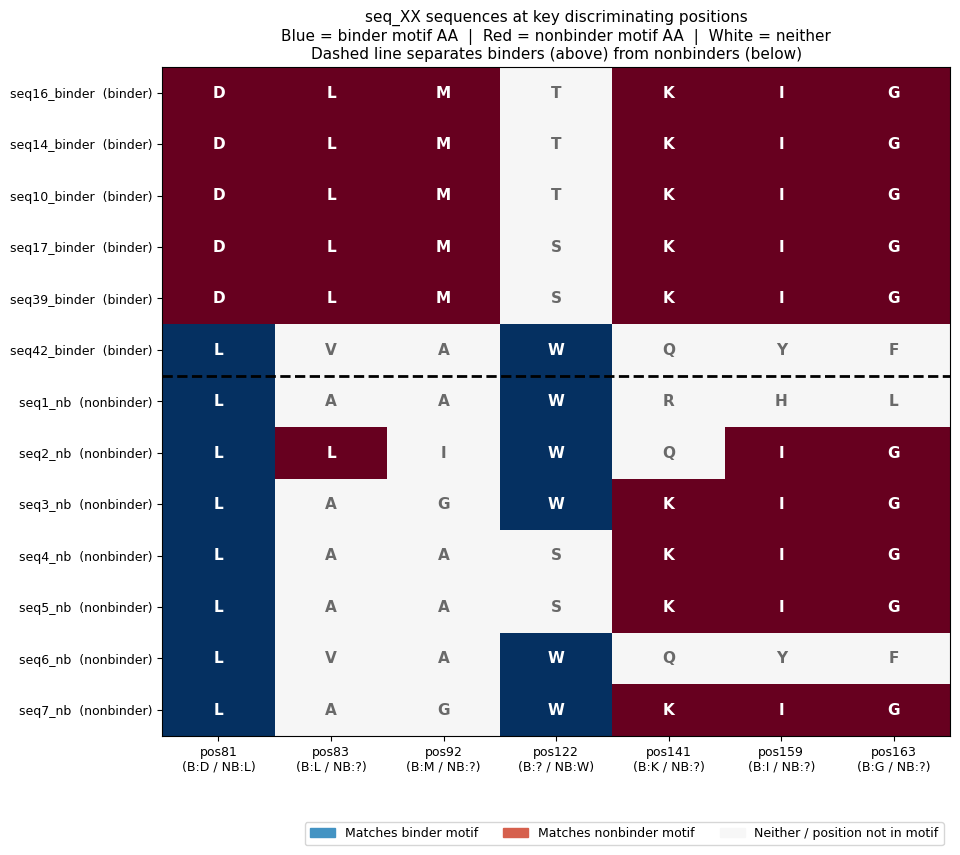


── Summary: do seq_XX binders carry the pair_3XXX binder motif? ──
  seq16_binder         match=6/6  | agree: pos81:D✓, pos83:L✓, pos92:M✓, pos141:K✓, pos159:I✓, pos163:G✓  | differ: none
  seq14_binder         match=6/6  | agree: pos81:D✓, pos83:L✓, pos92:M✓, pos141:K✓, pos159:I✓, pos163:G✓  | differ: none
  seq10_binder         match=6/6  | agree: pos81:D✓, pos83:L✓, pos92:M✓, pos141:K✓, pos159:I✓, pos163:G✓  | differ: none
  seq17_binder         match=6/6  | agree: pos81:D✓, pos83:L✓, pos92:M✓, pos141:K✓, pos159:I✓, pos163:G✓  | differ: none
  seq39_binder         match=6/6  | agree: pos81:D✓, pos83:L✓, pos92:M✓, pos141:K✓, pos159:I✓, pos163:G✓  | differ: none
  seq42_binder         match=0/6  | agree: none  | differ: pos81:L≠D, pos83:V≠L, pos92:A≠M, pos141:Q≠K, pos159:Y≠I, pos163:F≠G


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# seq_XX motif analysis
# Checks whether seq_XX binders carry the same amino acid pattern as
# pair_3XXX binders at the key discriminating positions, or whether they
# look like nonbinders — which determines if the motif is batch-driven
# or genuinely associated with binding.
# ══════════════════════════════════════════════════════════════════════════════

import re

# ── Key discriminating positions (1-indexed, from frequency analysis) ─────────
# Binder-enriched: pos81(D), pos83(L), pos92(M), pos141(K), pos159(I), pos163(G)
# Nonbinder-enriched: pos81(L), pos122(W)
KEY_POSITIONS = [81, 83, 92, 122, 141, 159, 163]   # 1-indexed

# ── Split sequences into four subgroups ───────────────────────────────────────
is_seq  = np.array([bool(re.match(r'^seq\d+', s)) for s in seq_ids])
is_pair = ~is_seq

subgroups = {
    "seq_XX binders":    np.where( is_seq  & is_binder)[0],
    "seq_XX nonbinders": np.where( is_seq  & ~is_binder)[0],
    "pair binders":      np.where( is_pair & is_binder)[0],
    "pair nonbinders":   np.where( is_pair & ~is_binder)[0],
}
for label, idx in subgroups.items():
    print(f"{label:<22}: n = {len(idx)}")

# ── Per-sequence AA table for seq_XX at key positions ─────────────────────────
print("\n── Amino acids at key positions for seq_XX sequences ──")
header_cols = [f"pos{p}" for p in KEY_POSITIONS]
rows = []
for idx in np.concatenate([subgroups["seq_XX binders"],
                            subgroups["seq_XX nonbinders"]]):
    row = {
        "name":  seq_ids[idx],
        "group": groups[idx],
    }
    for pos in KEY_POSITIONS:
        row[f"pos{pos}"] = sequences[idx][pos - 1].upper()
    rows.append(row)

seq_table = pd.DataFrame(rows).set_index("name")
print(seq_table.to_string())

# ── Frequency comparison across all four subgroups ────────────────────────────
print("\n── AA frequency at key positions across all subgroups ──")

# For each key position, count how often each AA appears in each subgroup
freq_rows = []
for pos in KEY_POSITIONS:
    aas_at_pos = set(sequences[i][pos-1].upper()
                     for i in range(len(sequences)))
    for aa in sorted(aas_at_pos):
        row = {"position": pos, "amino_acid": aa}
        for label, idx in subgroups.items():
            count = sum(sequences[i][pos-1].upper() == aa for i in idx)
            row[label] = f"{count}/{len(idx)} ({count/len(idx)*100:.0f}%)"
        freq_rows.append(row)

freq_comp = pd.DataFrame(freq_rows)
print(freq_comp.to_string(index=False))

# ── Visual: heatmap of AA at key positions, one row per seq_XX sequence ───────
# Colour by whether each residue matches the binder motif, nonbinder motif,
# or is ambiguous
BINDER_MOTIF    = {81: "D", 83: "L", 92: "M", 141: "K", 159: "I", 163: "G"}
NONBINDER_MOTIF = {81: "L", 122: "W"}

all_seq_idx = np.concatenate([subgroups["seq_XX binders"],
                               subgroups["seq_XX nonbinders"]])
n_seqs = len(all_seq_idx)
n_pos  = len(KEY_POSITIONS)

# Build colour matrix: 0=binder motif, 1=nonbinder motif, 0.5=neither
color_mat = np.full((n_seqs, n_pos), 0.5)
aa_labels = np.full((n_seqs, n_pos), "", dtype=object)

for row_i, seq_i in enumerate(all_seq_idx):
    for col_i, pos in enumerate(KEY_POSITIONS):
        aa = sequences[seq_i][pos - 1].upper()
        aa_labels[row_i, col_i] = aa
        if aa == BINDER_MOTIF.get(pos):
            color_mat[row_i, col_i] = 0.0   # binder motif → blue
        elif aa == NONBINDER_MOTIF.get(pos):
            color_mat[row_i, col_i] = 1.0   # nonbinder motif → red

row_labels = [f"{seq_ids[i]}  ({groups[i]})" for i in all_seq_idx]
divider    = len(subgroups["seq_XX binders"])   # line between binders/nonbinders

fig, ax = plt.subplots(figsize=(len(KEY_POSITIONS) * 1.1 + 2,
                                 n_seqs * 0.55 + 1.5))
im = ax.imshow(color_mat, cmap="RdBu", vmin=0, vmax=1,
               aspect="auto", interpolation="nearest")

# Annotate each cell with the amino acid letter
for row_i in range(n_seqs):
    for col_i in range(n_pos):
        ax.text(col_i, row_i, aa_labels[row_i, col_i],
                ha="center", va="center", fontsize=11, fontweight="bold",
                color="white" if color_mat[row_i, col_i] in [0.0, 1.0]
                       else "dimgray")

# Dividing line between binders and nonbinders
ax.axhline(divider - 0.5, color="black", lw=2, ls="--")

# Mark which column has a binder vs nonbinder motif AA in the header
ax.set_xticks(range(n_pos))
ax.set_xticklabels(
    [f"pos{p}\n(B:{BINDER_MOTIF.get(p,'?')} / NB:{NONBINDER_MOTIF.get(p,'?')})"
     for p in KEY_POSITIONS],
    fontsize=9,
)
ax.set_yticks(range(n_seqs))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title(
    "seq_XX sequences at key discriminating positions\n"
    "Blue = binder motif AA  |  Red = nonbinder motif AA  |  "
    "White = neither\n"
    "Dashed line separates binders (above) from nonbinders (below)",
    fontsize=11,
)

# Legend patches
legend_patches = [
    mpatches.Patch(color="#4393c3", label="Matches binder motif"),
    mpatches.Patch(color="#d6604d", label="Matches nonbinder motif"),
    mpatches.Patch(color="#f7f7f7", label="Neither / position not in motif"),
]
ax.legend(handles=legend_patches, loc="upper right",
          bbox_to_anchor=(1.0, -0.12), fontsize=9, ncol=3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "seqXX_motif_check.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Summary verdict ───────────────────────────────────────────────────────────
print("\n── Summary: do seq_XX binders carry the pair_3XXX binder motif? ──")
for seq_i in subgroups["seq_XX binders"]:
    matches = []
    mismatches = []
    for pos, motif_aa in BINDER_MOTIF.items():
        actual = sequences[seq_i][pos - 1].upper()
        if actual == motif_aa:
            matches.append(f"pos{pos}:{actual}✓")
        else:
            mismatches.append(f"pos{pos}:{actual}≠{motif_aa}")
    print(f"  {seq_ids[seq_i]:<20} "
          f"match={len(matches)}/6  "
          f"| agree: {', '.join(matches) if matches else 'none'}  "
          f"| differ: {', '.join(mismatches) if mismatches else 'none'}")


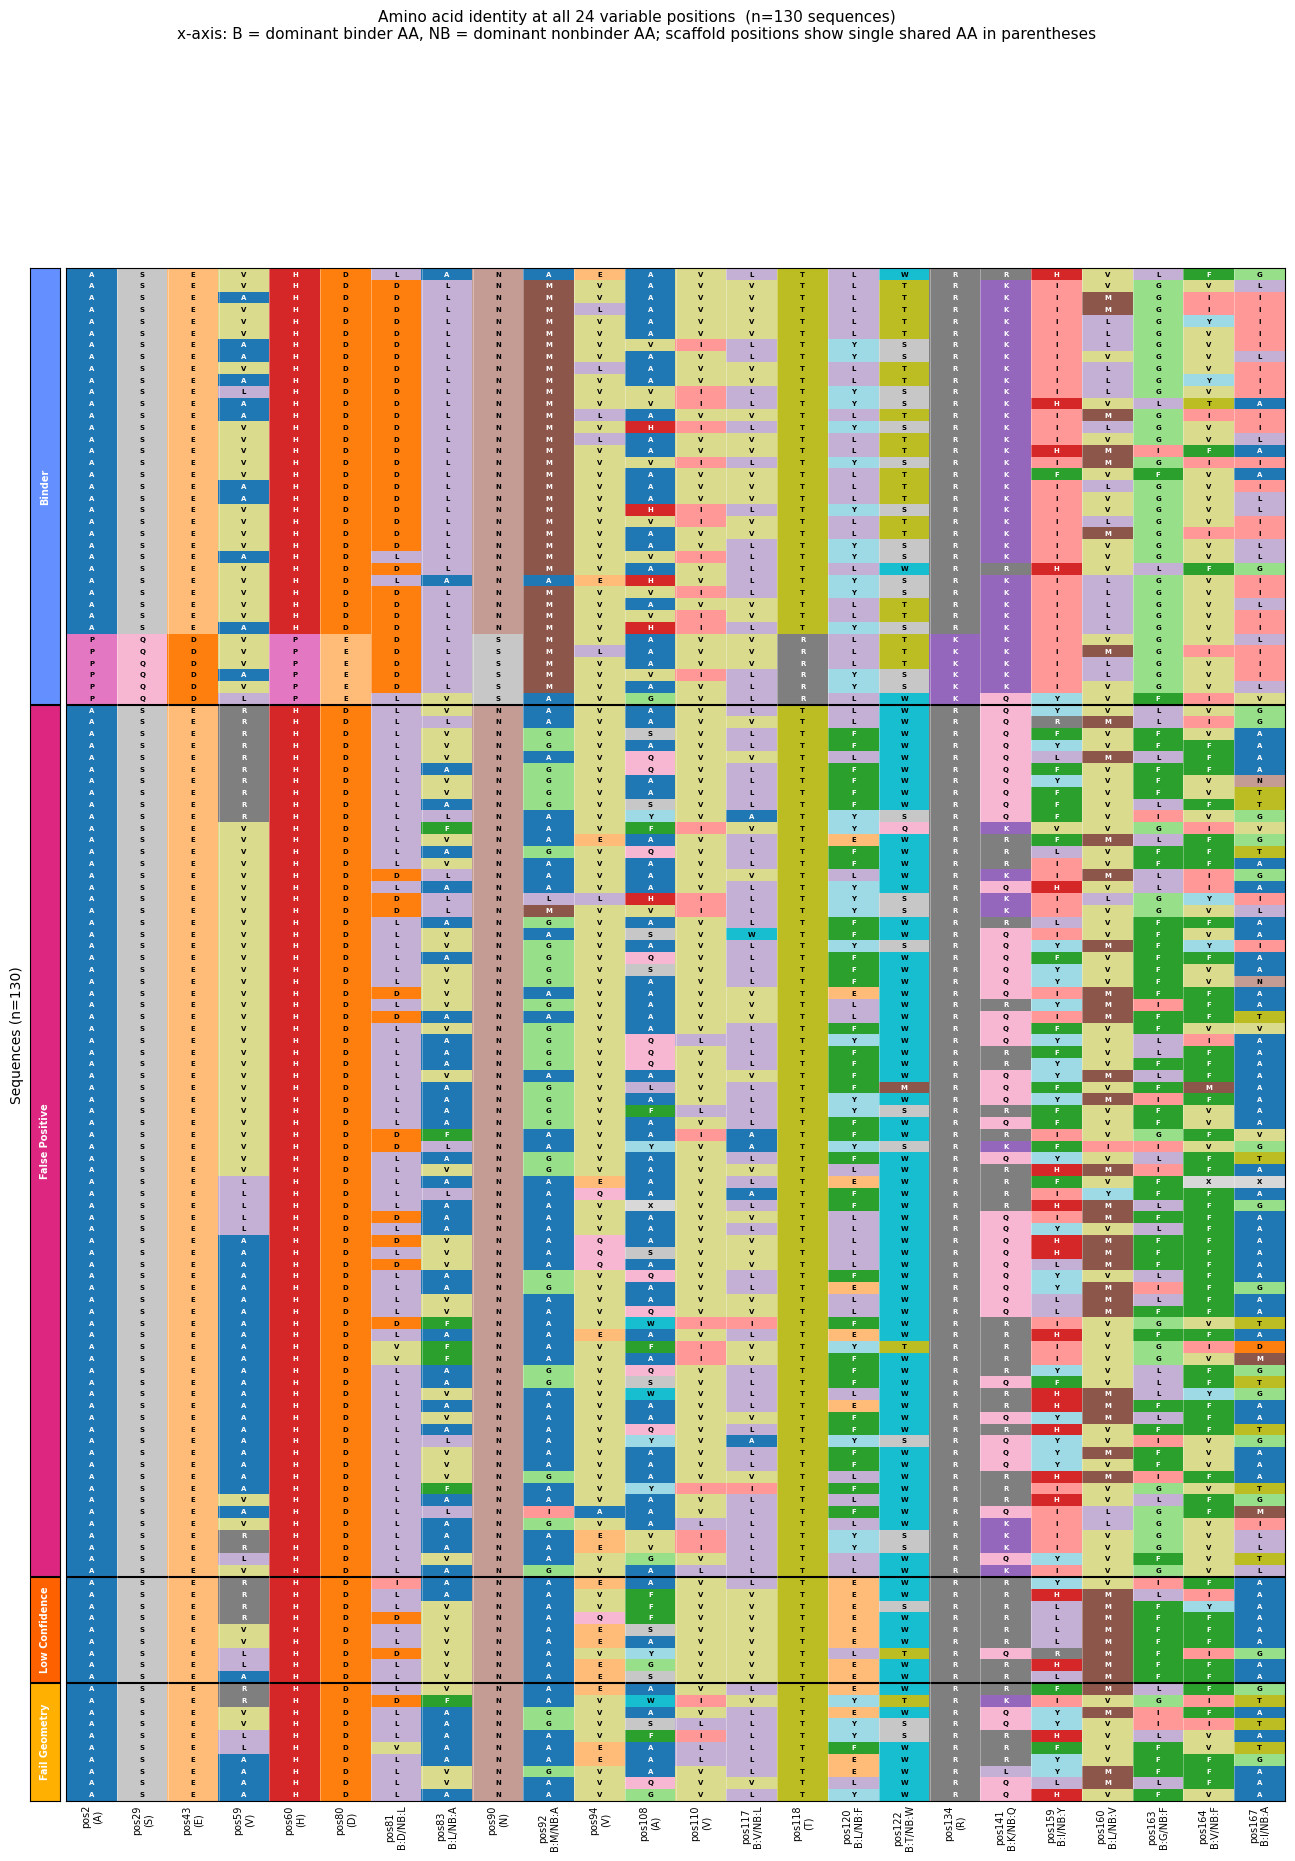

Discriminating positions (12): [np.int64(81), np.int64(83), np.int64(92), np.int64(117), np.int64(120), np.int64(122), np.int64(141), np.int64(159), np.int64(160), np.int64(163), np.int64(164), np.int64(167)]
Scaffold positions       (12): [np.int64(2), np.int64(29), np.int64(43), np.int64(59), np.int64(60), np.int64(80), np.int64(90), np.int64(94), np.int64(108), np.int64(110), np.int64(118), np.int64(134)]
Saved → /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/sequence_similarity/aa_frequency_by_group.csv
Shape : 96 rows × 23 columns
        (24 positions × 4 groups = 96 rows; 20 amino acid columns)

Discriminating positions only — first 3 shown:
                             A     D     F     G     I     L     M     V
position group                                                          
81       Binder            0.0  89.2   0.0   0.0   0.0  10.8   0.0   0.0
         False Positive    0.0  14.9   0.0   0.0   0.0  82.4   0.0   2.7
         Low C

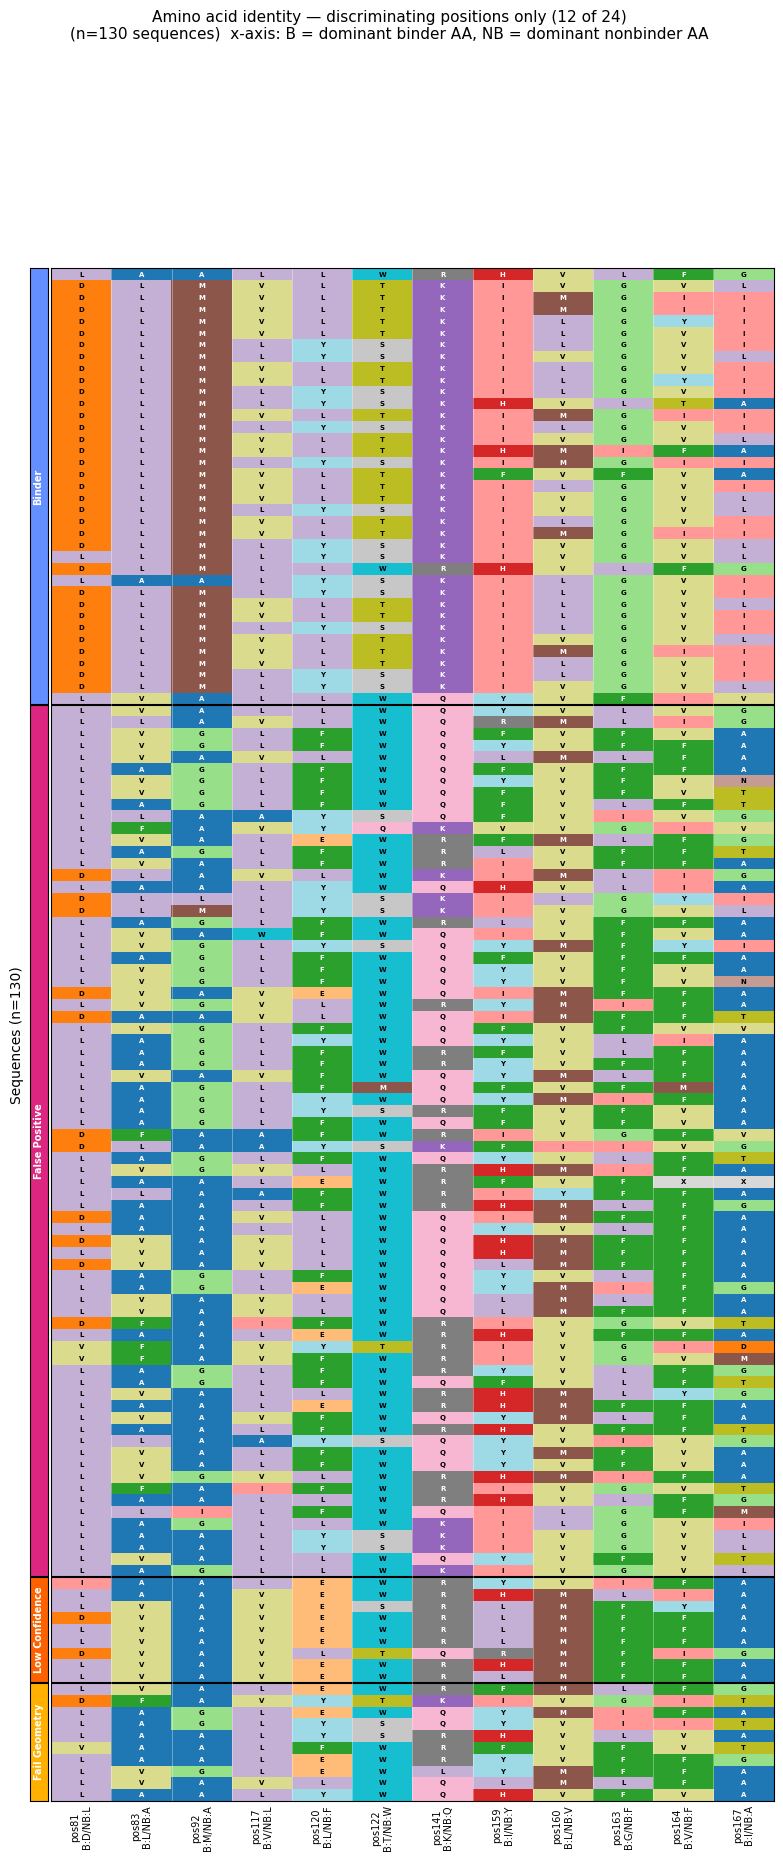

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Conserved motif summary — all 130 sequences × 24 variable positions
# Each unique amino acid has its own colour; group strip annotates rows
# ══════════════════════════════════════════════════════════════════════════════

# ── Unique colour per amino acid (tab20 gives 20 perceptually distinct colours)
AA_COLORS = {aa: plt.cm.tab20(i / 20) for i, aa in enumerate(AA_ORDER)}
AA_COLORS["X"] = (0.85, 0.85, 0.85, 1.0)   # unknown → light grey

def text_color(rgba):
    """Black or white text depending on background luminance."""
    r, g, b = rgba[:3]
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if lum < 0.55 else "black"

# ── Compute dominant AA per group per position ────────────────────────────────
b_seqs  = [sequences[i] for i in range(len(sequences)) if groups[i] == "binder"]
nb_seqs = [sequences[i] for i in range(len(sequences)) if groups[i] != "binder"]

dominant_b, dominant_nb = {}, {}
for pos in var_pos:
    b_counts  = {}
    nb_counts = {}
    for seq in b_seqs:
        aa = seq[pos].upper()
        b_counts[aa]  = b_counts.get(aa,  0) + 1
    for seq in nb_seqs:
        aa = seq[pos].upper()
        nb_counts[aa] = nb_counts.get(aa, 0) + 1
    dominant_b[pos]  = max(b_counts,  key=b_counts.get)
    dominant_nb[pos] = max(nb_counts, key=nb_counts.get)

is_scaffold = {pos: dominant_b[pos] == dominant_nb[pos] for pos in var_pos}

# ── Sort sequences: binders first, then nonbinder subgroups ──────────────────
GROUP_ORDER = ["binder", "nonbinder", "low_pkt", "fail_gate"]
sorted_idx  = sorted(range(len(sequences)),
                     key=lambda i: ({g: k for k, g in enumerate(GROUP_ORDER)}
                                    .get(groups[i], 99), seq_ids[i]))
grp_sorted  = [groups[i] for i in sorted_idx]
n_seqs = len(sorted_idx)
n_pos  = len(var_pos)

# ── Build RGBA colour array for imshow ───────────────────────────────────────
color_array = np.ones((n_seqs, n_pos, 4))   # default white
aa_grid     = np.empty((n_seqs, n_pos), dtype=object)

for row_i, seq_i in enumerate(sorted_idx):
    for col_i, pos in enumerate(var_pos):
        aa = sequences[seq_i][pos].upper()
        aa_grid[row_i, col_i]    = aa
        color_array[row_i, col_i] = AA_COLORS.get(aa, AA_COLORS["X"])

# ── Group boundaries (rows where group changes) ───────────────────────────────
# imshow origin='upper': row i sits at data-y = i, ylim = (n-0.5, -0.5)
# boundary between row k-1 and row k is at data-y = k - 0.5
boundaries = [k - 0.5 for k in range(1, n_seqs)
              if grp_sorted[k] != grp_sorted[k - 1]]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(max(14, n_pos * 0.55 + 3),
                           max(10, n_seqs * 0.13 + 3)))
gs  = fig.add_gridspec(1, 2, width_ratios=[0.025, 1], wspace=0.01)
ax_strip = fig.add_subplot(gs[0, 0])
ax_grid  = fig.add_subplot(gs[0, 1])

# ── Residue grid ──────────────────────────────────────────────────────────────
ax_grid.imshow(color_array, aspect="auto", interpolation="nearest")
# After imshow, ax_grid ylim = (n_seqs-0.5, -0.5)  [inverted, origin='upper']

for row_i in range(n_seqs):
    for col_i in range(n_pos):
        aa   = aa_grid[row_i, col_i]
        rgba = AA_COLORS.get(aa, AA_COLORS["X"])
        ax_grid.text(col_i, row_i, aa,
                     ha="center", va="center",
                     fontsize=5, fontweight="bold",
                     color=text_color(rgba))

for b in boundaries:
    ax_grid.axhline(b, color="black", lw=1.5)

# Subtle column dividers between positions
for col_i in range(n_pos - 1):
    ax_grid.axvline(col_i + 0.5, color="white", lw=0.4, alpha=0.6)

xlabels = []
for pos in var_pos:
    if is_scaffold[pos]:
        xlabels.append(f"pos{pos+1}\n({dominant_b[pos]})")
    else:
        xlabels.append(f"pos{pos+1}\nB:{dominant_b[pos]}/NB:{dominant_nb[pos]}")
ax_grid.set_xticks(range(n_pos))
ax_grid.set_xticklabels(xlabels, fontsize=7, rotation=90)
ax_grid.set_yticks([])
ax_grid.tick_params(axis="x", which="both", length=0, pad=3)

# ── Group colour strip ────────────────────────────────────────────────────────
# Match imshow y-coordinates exactly: ylim = (n_seqs-0.5, -0.5), origin='upper'
ax_strip.set_xlim(0, 1)
ax_strip.set_ylim(n_seqs - 0.5, -0.5)   # ← inverted to match imshow
ax_strip.set_xticks([])
ax_strip.set_yticks([])
ax_strip.set_ylabel(f"Sequences (n={n_seqs})", fontsize=10, labelpad=4)

for i in range(n_seqs):
    ax_strip.add_patch(plt.Rectangle(
        (0, i - 0.5), 1, 1,            # y from i-0.5 to i+0.5 in data coords
        color=GROUP_COLORS.get(grp_sorted[i], "#aaaaaa"),
        transform=ax_strip.transData,
    ))

# Centred group name labels
seen = {}
for i, g in enumerate(grp_sorted):
    if g not in seen:
        seen[g] = i
for g, start_i in seen.items():
    end_i = next((j for j in range(start_i + 1, n_seqs)
                  if grp_sorted[j] != g), n_seqs)
    mid   = (start_i + end_i - 1) / 2   # centre row index
    ax_strip.text(0.5, mid, DISPLAY_LABEL.get(g, g),
                  ha="center", va="center", fontsize=7,
                  rotation=90, color="white", fontweight="bold")

for b in boundaries:
    ax_strip.axhline(b, color="black", lw=1.5)

fig.suptitle(
    f"Amino acid identity at all {n_pos} variable positions  "
    f"(n={n_seqs} sequences)\n"
    "x-axis: B = dominant binder AA, NB = dominant nonbinder AA; "
    "scaffold positions show single shared AA in parentheses",
    fontsize=11, y=1.01,
)
plt.savefig(os.path.join(OUT_DIR, "conserved_motif_summary.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Print discriminating vs scaffold positions ────────────────────────────────
disc_pos = [pos for pos in var_pos if not is_scaffold[pos]]
scaf_pos = [pos for pos in var_pos if     is_scaffold[pos]]
print(f"Discriminating positions ({len(disc_pos)}): {[p+1 for p in disc_pos]}")
print(f"Scaffold positions       ({len(scaf_pos)}): {[p+1 for p in scaf_pos]}")



# ── Per-group AA frequency table → CSV ───────────────────────────────────────
# Row index  : two levels — (position, group)
# Columns    : one per unique amino acid observed across the dataset
# Cell values: frequency (%) of that amino acid in that group at that position

all_groups = ["binder", "nonbinder", "low_pkt", "fail_gate"]
group_seqs = {g: [sequences[i] for i in range(len(sequences))
                   if groups[i] == g]
              for g in all_groups}
group_n    = {g: len(v) for g, v in group_seqs.items()}

# Amino acids that appear at least once across all variable positions
present_aas = sorted({
    sequences[i][pos].upper()
    for i in range(len(sequences))
    for pos in var_pos
    if sequences[i][pos].upper() in AA_COLORS
})

# Build rows: one per (position, group) combination
table_rows = []
for pos in var_pos:
    for g in all_groups:
        n   = group_n[g]
        row = {
            "position":   pos + 1,
            "group":      DISPLAY_LABEL[g],
            "n":          n,
            "dominant_AA": dominant_b[pos] if g == "binder" else dominant_nb[pos],
            "is_scaffold": is_scaffold[pos],
        }
        for aa in present_aas:
            count    = sum(seq[pos].upper() == aa for seq in group_seqs[g])
            row[aa]  = round(count / n * 100, 1) if n > 0 else 0.0
        table_rows.append(row)

flat = pd.DataFrame(table_rows)

# Two-level row index: (position, group)
freq_table = flat.set_index(["position", "group"])

# Save to CSV
out_path = os.path.join(OUT_DIR, "aa_frequency_by_group.csv")
freq_table.to_csv(out_path)
print(f"Saved → {out_path}")
print(f"Shape : {freq_table.shape[0]} rows × {freq_table.shape[1]} columns")
print(f"        ({len(var_pos)} positions × {len(all_groups)} groups = "
      f"{len(var_pos)*len(all_groups)} rows; "
      f"{len(present_aas)} amino acid columns)")

# Preview: discriminating positions only
disc_pos_1idx = [pos + 1 for pos in var_pos if not is_scaffold[pos]]
print(f"\nDiscriminating positions only — first 3 shown:")
preview = freq_table.loc[disc_pos_1idx[:3], present_aas]
# Drop all-zero columns for readability
preview = preview.loc[:, (preview != 0).any(axis=0)]
print(preview.to_string())

# ── Conserved motif plot — discriminating positions only ──────────────────────
disc_var_pos = [pos for pos in var_pos if not is_scaffold[pos]]
n_disc       = len(disc_var_pos)
print(f"Discriminating positions ({n_disc}): {[p+1 for p in disc_var_pos]}")

# Rebuild colour array for discriminating positions only
color_array_disc = np.ones((n_seqs, n_disc, 4))
aa_grid_disc     = np.empty((n_seqs, n_disc), dtype=object)

for row_i, seq_i in enumerate(sorted_idx):
    for col_i, pos in enumerate(disc_var_pos):
        aa = sequences[seq_i][pos].upper()
        aa_grid_disc[row_i, col_i]     = aa
        color_array_disc[row_i, col_i] = AA_COLORS.get(aa, AA_COLORS["X"])

fig2 = plt.figure(figsize=(max(6, n_disc * 0.55 + 3),
                            max(10, n_seqs * 0.13 + 3)))
gs2      = fig2.add_gridspec(1, 2, width_ratios=[0.025, 1], wspace=0.01)
ax_strip2 = fig2.add_subplot(gs2[0, 0])
ax_grid2  = fig2.add_subplot(gs2[0, 1])

# ── Residue grid ──────────────────────────────────────────────────────────────
ax_grid2.imshow(color_array_disc, aspect="auto", interpolation="nearest")

for row_i in range(n_seqs):
    for col_i in range(n_disc):
        aa   = aa_grid_disc[row_i, col_i]
        rgba = AA_COLORS.get(aa, AA_COLORS["X"])
        ax_grid2.text(col_i, row_i, aa,
                      ha="center", va="center",
                      fontsize=5, fontweight="bold",
                      color=text_color(rgba))

for b in boundaries:
    ax_grid2.axhline(b, color="black", lw=1.5)
for col_i in range(n_disc - 1):
    ax_grid2.axvline(col_i + 0.5, color="white", lw=0.4, alpha=0.6)

xlabels2 = [f"pos{pos+1}\nB:{dominant_b[pos]}/NB:{dominant_nb[pos]}"
            for pos in disc_var_pos]
ax_grid2.set_xticks(range(n_disc))
ax_grid2.set_xticklabels(xlabels2, fontsize=7, rotation=90)
ax_grid2.set_yticks([])
ax_grid2.tick_params(axis="x", which="both", length=0, pad=3)

# ── Group colour strip ────────────────────────────────────────────────────────
ax_strip2.set_xlim(0, 1)
ax_strip2.set_ylim(n_seqs - 0.5, -0.5)
ax_strip2.set_xticks([])
ax_strip2.set_yticks([])
ax_strip2.set_ylabel(f"Sequences (n={n_seqs})", fontsize=10, labelpad=4)

for i in range(n_seqs):
    ax_strip2.add_patch(plt.Rectangle(
        (0, i - 0.5), 1, 1,
        color=GROUP_COLORS.get(grp_sorted[i], "#aaaaaa"),
        transform=ax_strip2.transData,
    ))

seen2 = {}
for i, g in enumerate(grp_sorted):
    if g not in seen2:
        seen2[g] = i
for g, start_i in seen2.items():
    end_i = next((j for j in range(start_i + 1, n_seqs)
                  if grp_sorted[j] != g), n_seqs)
    mid   = (start_i + end_i - 1) / 2
    ax_strip2.text(0.5, mid, DISPLAY_LABEL.get(g, g),
                   ha="center", va="center", fontsize=7,
                   rotation=90, color="white", fontweight="bold")

for b in boundaries:
    ax_strip2.axhline(b, color="black", lw=1.5)

fig2.suptitle(
    f"Amino acid identity — discriminating positions only ({n_disc} of {n_pos})\n"
    f"(n={n_seqs} sequences)  "
    "x-axis: B = dominant binder AA, NB = dominant nonbinder AA",
    fontsize=11, y=1.01,
)
plt.savefig(os.path.join(OUT_DIR, "conserved_motif_discriminating.png"),
            dpi=150, bbox_inches="tight")
plt.show()
